In [2]:
import os
import pandas as pd
import ollama

In [3]:
ordner = r"C:\Users\Klara Ellensohn\Documents\GitHub\datascienceapplicaionts_media\sentiment_project"



In [4]:
def classify_gender(text):
    prompt = f"""
    Bestimme das Geschlecht der Sportler:innen, über die dieser Artikel berichtet.
    Kategorien:
    - männlich
    - weiblich
    - gemischt
    - unklar

    Gib NUR eine der vier Kategorien aus.

    Text:
    {text}
    """

    response = ollama.generate(
        model="llama3.1",
        prompt=prompt
    )

    label = response["response"].strip().lower()

    if label not in ["männlich", "weiblich", "gemischt", "unklar"]:
        label = "unklar"

    return label


In [5]:
ergebnisse = []

dateien = [d for d in os.listdir(ordner) if d.endswith(".txt")]

for i, datei in enumerate(dateien, start=1):
    print(f"→ Verarbeite Datei {i}/{len(dateien)}: {datei}")

    pfad = os.path.join(ordner, datei)

    with open(pfad, "r", encoding="utf-8") as f:
        text = f.read()

    gender = classify_gender(text)

    ergebnisse.append({
        "datei": datei,
        "geschlecht": gender
    })

df = pd.DataFrame(ergebnisse)
df


→ Verarbeite Datei 1/30: atscher Hinrunde „Gefühlt gab es vi.txt
→ Verarbeite Datei 2/30: basketball_eurosport.txt
→ Verarbeite Datei 3/30: Bereits am Vormittag stieg im Biath.txt
→ Verarbeite Datei 4/30: Carlos Alcaraz trennt sich von sein.txt
→ Verarbeite Datei 5/30: Champions League.txt
→ Verarbeite Datei 6/30: champions-league_eurosport.txt
→ Verarbeite Datei 7/30: Der SSV Bozen steckt aktuell in ein.txt
→ Verarbeite Datei 8/30: Die Bayern stehen schon im Viertelf.txt
→ Verarbeite Datei 9/30: Die Scottish Open vom 15. bis zum 2.txt
→ Verarbeite Datei 10/30: Ehemaliger Kitz-Sieger Sarrazin zur.txt
→ Verarbeite Datei 11/30: Emma Aicher mischt den alpinen Ski-.txt
→ Verarbeite Datei 12/30: environments.txt
→ Verarbeite Datei 13/30: Europacup.txt
→ Verarbeite Datei 14/30: Für den HC Eppan war es zweifelsohn.txt
→ Verarbeite Datei 15/30: Für Gregoritsch zählt der Teamgeist.txt
→ Verarbeite Datei 16/30: Gasslitter ist gut, aber nicht gut.txt
→ Verarbeite Datei 17/30: gemischte_gefühle_eu

,datei,geschlecht
0,atscher Hinrunde „Gefühlt gab es vi.txt,männlich
1,basketball_eurosport.txt,männlich
2,Bereits am Vormittag stieg im Biath.txt,männlich
3,Carlos Alcaraz trennt sich von sein.txt,männlich
4,Champions League.txt,weiblich
5,champions-league_eurosport.txt,unklar
6,Der SSV Bozen steckt aktuell in ein.txt,unklar
7,Die Bayern stehen schon im Viertelf.txt,unklar
8,Die Scottish Open vom 15. bis zum 2.txt,unklar
9,Ehemaliger Kitz-Sieger Sarrazin zur.txt,männlich


In [6]:
df.to_csv("geschlechteranalyse_ollama.csv", index=False, encoding="utf-8")

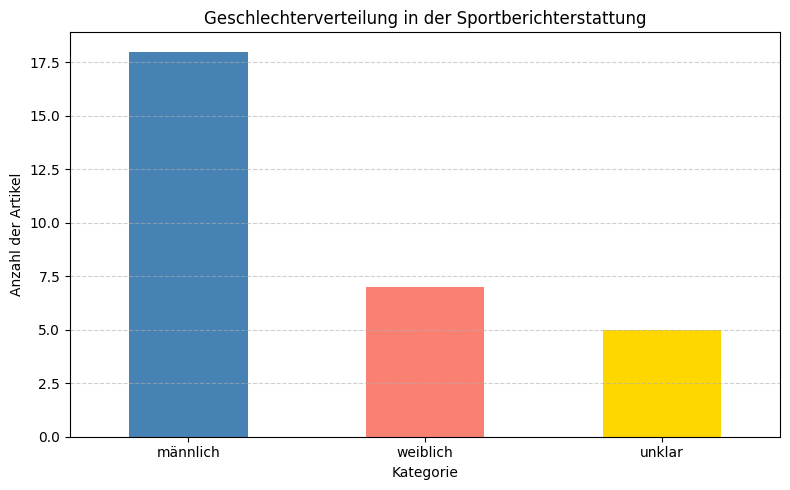

In [7]:
import matplotlib.pyplot as plt

counts = df["geschlecht"].value_counts()

plt.figure(figsize=(8, 5))
counts.plot(kind="bar", color=["steelblue", "salmon", "gold", "gray"])

plt.title("Geschlechterverteilung in der Sportberichterstattung")
plt.xlabel("Kategorie")
plt.ylabel("Anzahl der Artikel")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
